# Signature-Based Image Distance — Method A: Patch Singular-Value Stream

## Motivation

Every Lipschitz estimate in this project's Experiment 2 (`mnist_lipschitz`) reduces to the
same ratio, `|margin_i - margin_j| / distance(x_i, x_j)` — and every denominator tried so
far has been a distance over the *raw pixel grid*. This sub-project builds a distance from
**path signatures** of low-dimensional streams extracted from the image instead.

**This notebook covers Method A only** (patch singular-value stream) — Method B (reference-line
stream) has its own notebook, `notebook_method_b.ipynb`.

- **Method A — patch singular-value stream**: visit a fixed, shared set of 64 interior pixel
  locations; at each, take the largest singular value of the surrounding 3x3 patch. Stream:
  `(64, 2)`, columns `[t, sigma1]`.
- **Signature**: the stream's truncated signature (depth 4), computed via `signatures.py` — the
  function shared with Method B, so results between the two methods are directly comparable.
  Full design/rationale: `PLAN.md`.

The pixel locations are fixed and shared across every image (no dependence on a trained
classifier's own features), so the resulting streams — and their signatures — are directly
comparable across images.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

from signature_distance import run_experiment

## Build Method A streams and signatures for one sample image per digit

`method_a_demo` (in `run_experiment.py`) loads the fixed 1000-image eval pool
(`data_pool.load_eval_pool`), builds the 64 pixel locations once (shared across every image),
and for one sample image per digit: constructs the stream, computes its signature, and saves
an overlay + stream + signature plot to `results/`.

pool: torch.Size([1000, 28, 28]) torch.Size([1000])
pixel_order: torch.Size([64, 2])


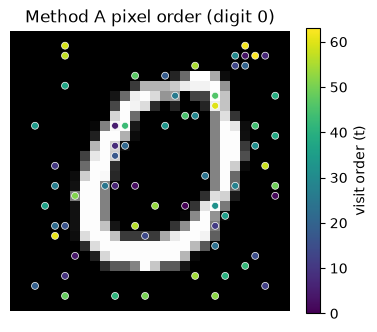

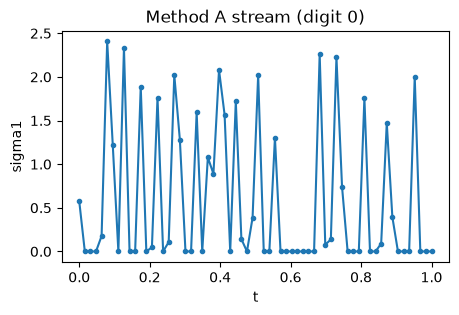

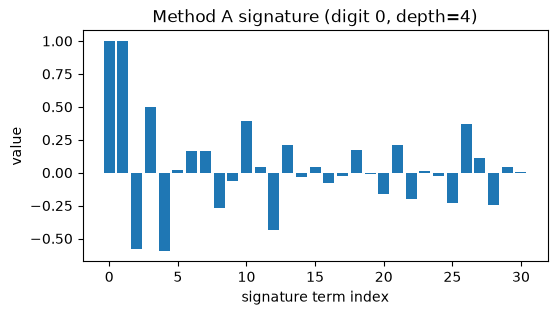

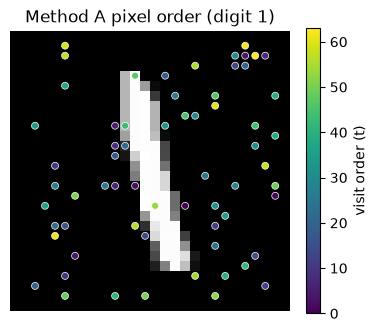

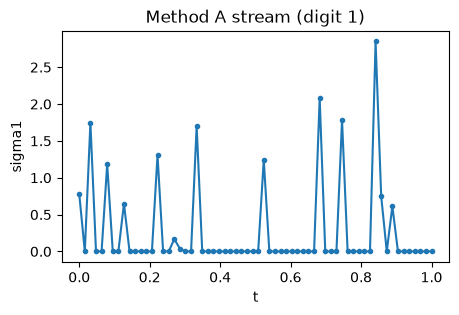

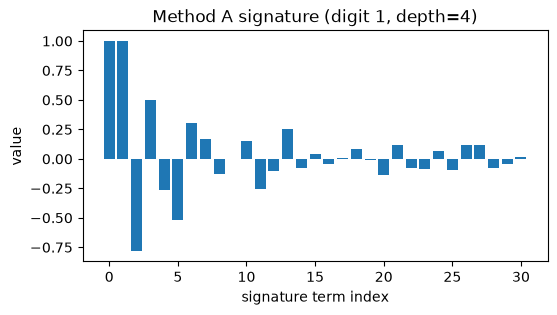

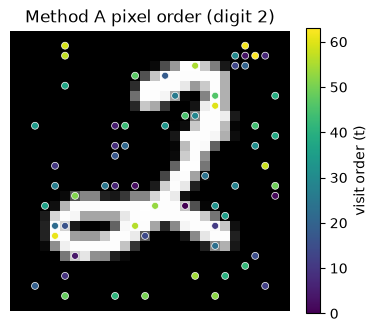

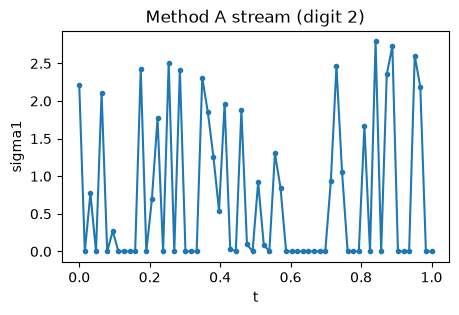

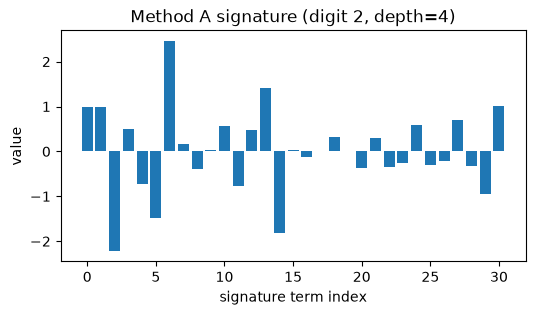

In [2]:
result = run_experiment.method_a_demo(n_digits=3)
print('pool:', result['images'].shape, result['labels'].shape)
print('pixel_order:', result['pixel_order'].shape)

## Pixel-order overlay, stream, and signature, per digit

Each digit shows three panels:
1. The 64 sampled interior patch-locations overlaid on the image, colored by visit order `t`.
2. The resulting `sigma1` vs. `t` stream — should visibly respond to whichever part of the
   digit's stroke each patch lands on.
3. The stream's truncated signature (depth 4, 31 coefficients). Index 0 is always the constant
   term (1.0); indices 1-2 are the net displacement of the `[t, sigma1]` path (`t` always ends
   at 1, so index 1 is always 1.0 too — see `signatures.py`'s closed-form tests); the rest
   capture higher-order shape of the path.

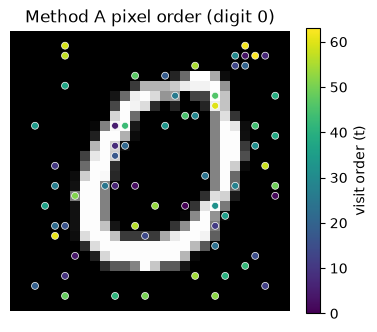

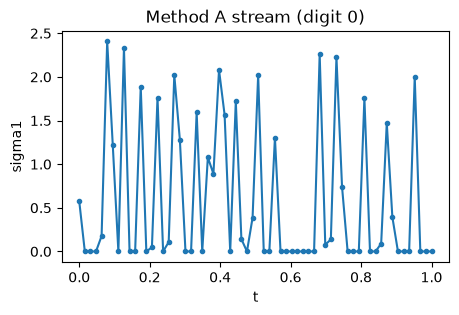

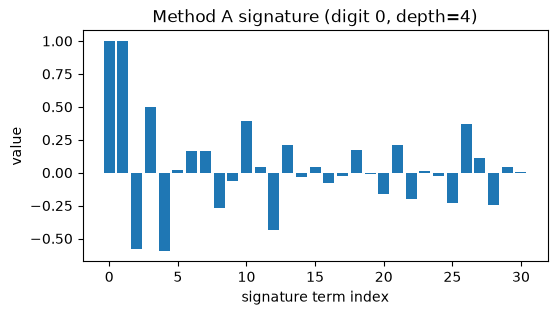

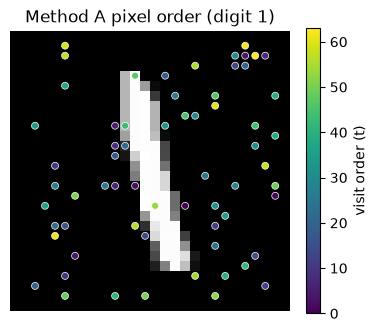

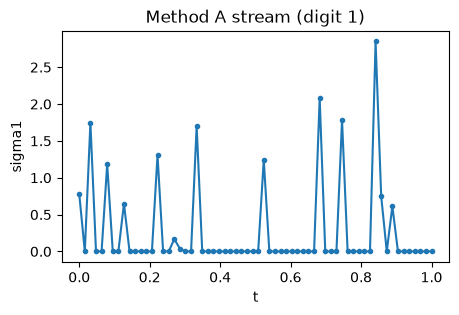

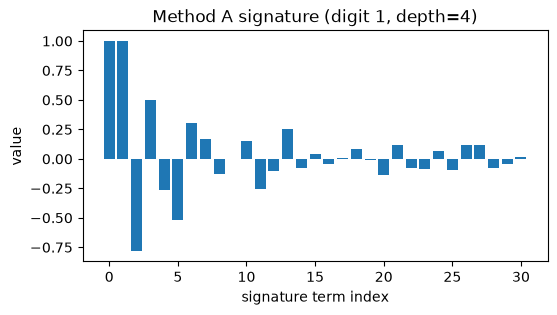

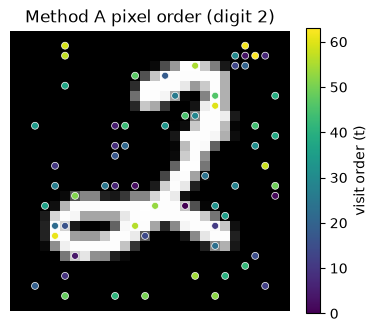

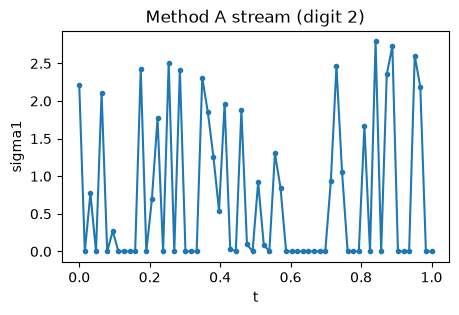

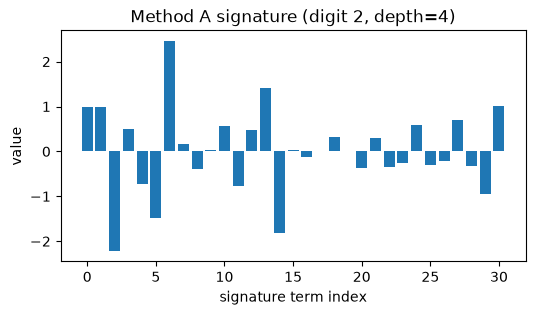

In [3]:
for digit in range(3):
    display(result['figures'][f'digit{digit}_overlay'])
    display(result['figures'][f'digit{digit}_stream'])
    display(result['figures'][f'digit{digit}_signature'])

## Status

Method A produces visually sane streams and signatures for every digit shown above — patch
locations stay interior, `sigma1` tracks the stroke, and every signature's constant term is
1.0 and finite. `signature_of_stream` (shared with Method B) is verified against closed-form
identities in `tests/test_signatures.py` / `tests/test_signatures_method_b.py` — a straight-line
path's signature matches the exact tensor exponential, and an L-shaped path matches a
hand-computed area term — before being trusted here.

Phase 3 (distance function over the signature) and Phase 4 (within/cross-digit sanity check)
have since landed (`distances.py`, `run_experiment.sanity_check_demo`) — Method A's numbers are
`r ≈ 1.656`, within-digit mean 14.60, cross-digit mean 17.18, ratio 1.176 (documented in
`README.md`'s Results section; this notebook hasn't been re-executed to show that cell directly).
The section below runs a further diagnostic on top of that same Phase 3/4 pipeline.</cell>


## Level-wise decomposition of the signature distance

Method A's stream is `(t, sigma1)`, and the time channel is identical for every image
(`arange(64)/63`), so it contributes exactly zero to any pairwise distance. That means the
entire level-1 content of the signature reduces to a single scalar:
`Δσ1 = sigma1(anchor 63) − sigma1(anchor 0)` — the difference of two 3x3 patch singular values
out of 64 anchors. If the Phase 4 ratio (1.176) turned out to be carried entirely by that one
scalar, the signature machinery at levels 2-4 would be doing no work.

`level_decomposition.py` checks this directly (read-only diagnostic, doesn't change the
distance/stream/signature pipeline above): masks the rescaled signature down to specific levels
before computing the same within/cross-digit sanity check, on the same 300-image sample
(30/class, seed 0) `run_experiment.sanity_check_demo` uses. Full detail (both methods, per-level
squared-distance contribution table): `level_decomposition_summary.md`.

In [4]:
import json

from signature_distance.level_decomposition import run_level_decomposition

decomposition = run_level_decomposition(n_per_class=30, seed=0, depth=4)

print('r_a:', decomposition['r_a'])
print()
print('variants (method_a):')
print(json.dumps(
    {label: entry['method_a'] for label, entry in decomposition['variants'].items()},
    indent=2,
))
print()
print('per-level fraction of total squared distance (method_a):')
print(json.dumps(decomposition['level_fraction']['method_a'], indent=2))

r_a: 1.6562803550838685

variants (method_a):
{
  "all": {
    "within_digit_mean": 14.601262092590332,
    "cross_digit_mean": 17.176847457885742,
    "ratio_cross_over_within": 1.1763947081398145
  },
  "level1_only": {
    "within_digit_mean": 1.4976658821105957,
    "cross_digit_mean": 1.9109092950820923,
    "ratio_cross_over_within": 1.275924969586094
  },
  "level2plus": {
    "within_digit_mean": 14.503375053405762,
    "cross_digit_mean": 17.045394897460938,
    "ratio_cross_over_within": 1.175270916920696
  },
  "level2_only": {
    "within_digit_mean": 4.544910430908203,
    "cross_digit_mean": 5.580888271331787,
    "ratio_cross_over_within": 1.2279424107851045
  },
  "level3_only": {
    "within_digit_mean": 7.8995490074157715,
    "cross_digit_mean": 9.377066612243652,
    "ratio_cross_over_within": 1.187038222491037
  },
  "level4_only": {
    "within_digit_mean": 11.17805290222168,
    "cross_digit_mean": 12.98395824432373,
    "ratio_cross_over_within": 1.1615581316262

**Finding: the higher-order levels carry the signal, not the level-1 scalar.** `level2plus`
(levels 2-4, level 1 dropped entirely) reproduces the full `all` ratio almost exactly
(1.175 vs. 1.176) — dropping the single `Δσ1` scalar costs almost nothing. The per-level
fraction table sharpens this further: level 1 carries only ~1.8% of the total squared
pairwise distance, versus ~58% for level 4 alone. So Method A's Phase 4 ratio is not a
relabelled version of `Δσ1` — that scalar is a minor contributor, and the signature machinery
above it is doing real work.

One wrinkle worth keeping in mind rather than smoothing over: level 1 alone actually posts the
*highest* individual-level ratio (1.276, above `all`'s 1.176) despite its tiny magnitude share —
a level can be a relatively good per-unit class-separator while barely moving the distance in
absolute terms. Ratio and magnitude are answering different questions, and neither alone is
the full picture (see `level_decomposition_summary.md` for the same pattern, inverted, at
level 4). Per this project's convention, this is carried forward as an honest finding, not
argued away — it doesn't change Phase 4's already-documented modest effect size relative to the
pixel-space Euclidean baseline.

## Pixel-order robustness check

README.md flags Method A's pixel visiting order (`make_pixel_order`, a seeded
`torch.randperm`) as "a random sample, not a spatially coherent walk" — worth checking whether
the level-decomposition finding above depends on which particular 64-pixel sample/order was
used, or holds regardless.

`run_level_decomposition` takes an optional `pixel_order_seed`, independent of `seed` (which
controls the eval pool) — it defaults to reusing `seed`, so the cell above was implicitly
`pixel_order_seed=0`. Below: the same 300-image pool (seed 0) held fixed throughout, run for 4
more pixel orders (`pixel_order_seed` 1-4) and compared against the seed-0 baseline above.
Method B is unaffected either way — `make_reference_lines`'s line geometry doesn't depend on a
seed.

In [5]:
import pandas as pd

pixel_order_seeds = [0, 1, 2, 3, 4]
po_results = {
    s: run_level_decomposition(n_per_class=30, seed=0, depth=4, pixel_order_seed=s)
    for s in pixel_order_seeds
}

print('r_a per pixel_order_seed:')
display(pd.Series({s: r['r_a'] for s, r in po_results.items()}, name='r_a').to_frame())

ratio_table = pd.DataFrame({
    s: {v: entry['method_a']['ratio_cross_over_within'] for v, entry in r['variants'].items()}
    for s, r in po_results.items()
})
print('ratio (cross/within) per variant, per pixel_order_seed:')
display(ratio_table.round(4))

fraction_table = pd.DataFrame({
    s: r['level_fraction']['method_a'] for s, r in po_results.items()
})
print('per-level squared-distance fraction (%), per pixel_order_seed:')
display((fraction_table * 100).round(2))

r_a per pixel_order_seed:


,r_a
0,1.656280
1,1.500071
2,1.500396
3,1.583648
4,1.571740


ratio (cross/within) per variant, per pixel_order_seed:


,0,1,2,3,4
all,1.1764,1.2549,1.1890,1.2186,1.2780
level1_only,1.2759,1.4191,1.2738,1.2680,1.3667
level2plus,1.1753,1.2527,1.1873,1.2184,1.2776
level2_only,1.2279,1.3668,1.1958,1.2552,1.3521
level3_only,1.1870,1.2660,1.2140,1.2288,1.3115
level4_only,1.1616,1.2277,1.1751,1.2095,1.2534


per-level squared-distance fraction (%), per pixel_order_seed:


,0,1,2,3,4
1,1.79,3.06,4.04,1.77,2.33
2,11.35,13.12,11.46,11.54,12.32
3,28.85,24.73,27.80,28.82,27.02
4,58.01,59.09,56.70,57.87,58.33


**Finding: the two conclusions above are robust across pixel orders — only the effect size moves.**

The `all`-variant ratio ranges 1.176–1.278 across the 5 orders (mean ≈1.223, std ≈0.038, ~8%
peak-to-peak) — a real, moderate sensitivity to exactly which 64 interior pixels get sampled and
in what order, consistent with the "random sample, not a spatially coherent walk" caveat this
check was meant to test. `r_a` moves similarly (1.500–1.656).

But the two qualitative findings from the level decomposition above hold in *every* one of the 5
pixel orders, not just the original:

1. **`level2plus ≈ all`, always.** The gap between them is ≤0.004 in every row — dropping level 1
   entirely never costs anything meaningful, regardless of which pixels/order were used. Verdict
   (b) (higher-order levels carry the signal) isn't an artifact of one particular sample.
2. **Level 1 is always the "high ratio, low magnitude" outlier.** `level1_only` has the *highest*
   per-level ratio in all 5 orders (up to 1.419 at `pixel_order_seed=1`), while carrying the
   least magnitude every time (1.8–4.0%, always under 5%). `level4_only` is the mirror image:
   lowest ratio, most magnitude (57–59%), in all 5 orders. Magnitude fraction increases
   monotonically level 1→4 in every run; the ratio ordering is not perfectly monotonic (level 3
   edges out level 2 at `pixel_order_seed=2`), but level 1 highest / level 4 lowest never breaks.

Per this project's convention, this is carried forward as the honest picture: the *direction* and
*shape* of the level-decomposition finding is stable, but the specific numbers (and Method A's
headline Phase 4 ratio itself) depend non-trivially on the particular random pixel sample —
worth keeping in mind before treating any single run's ratio as a precise, reproducible constant.